


**Contents**
1. Setup
2. Data Loading
3. Data Quality Assessment
4. Data Cleaning
5. Feature Engineering
6. Exploratory Visualizations
7. Feature & Target Understanding
8. Initial Findings & Next Steps



## 1. Setup
Standard imports and plotting defaults.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore') #
sns.set_theme(style="whitegrid") #
%matplotlib inline

## 2. Data Loading

We load the raw CMS CSV with explicit `dtype` overrides for identifier-like columns (NPI, ZIP, FIPS, HCPCS code, RUCA) so pandas does not try to infer them as numeric — these are categorical/ID fields even though they look numeric. After the first load we cache the data as a Parquet file so subsequent runs are much faster and use less memory.


In [2]:
CSV_PATH = "Medicare_Physician_Other_Practitioners_by_Provider_and_Service_2024.csv" #
PARQUET_PATH = "Medicare_Physician_2024_Cached.parquet"

# Load with defined dtypes to optimize memory footprint
data = pd.read_csv(
    CSV_PATH,
    dtype={
        "Rndrng_NPI": str,
        "Rndrng_Prvdr_Zip5": str,
        "Rndrng_Prvdr_State_FIPS": str,
        "HCPCS_Cd": str,
        "Rndrng_Prvdr_RUCA": str,
    },
    low_memory=False,
) #

print(f"Shape: {data.shape}") #
print(f"Memory usage: {data.memory_usage(deep=True).sum() / 1e9:.2f} GB") #

# Convert and cache to Parquet format for future performance
data.to_parquet(PARQUET_PATH, index=False)

Shape: (9781673, 28)
Memory usage: 4.72 GB


## 3. Data Quality Assessment

### 3.1 Structure, Data Types & Missing Values

The table below profiles every column: its dtype, number of unique values, missing-value count/percentage, and a representative example value. This resolves ambiguity around a few similarly-named amount columns in the dataset:

| Column | Meaning |
|---|---|
| `Rndrng_NPI` | National Provider Identifier — unique ID for the billing provider (not a numeric feature, a key) |
| `Rndrng_Prvdr_Type` | Provider specialty/type (e.g., Internal Medicine, Cardiology); ~200 distinct values |
| `HCPCS_Cd` / `HCPCS_Desc` | Procedure/service code and its plain-language description |
| `HCPCS_Drug_Ind` | `Y`/`N` — whether the HCPCS code is a Part B drug (Average Sales Price) code |
| `Place_Of_Srvc` | `F` = facility (e.g., hospital), `O` = non-facility (e.g., office) |
| `Tot_Benes` | Distinct Medicare beneficiaries who received this NPI × HCPCS × place-of-service combination |
| `Tot_Srvcs` | Total number of services billed for that combination |
| `Tot_Bene_Day_Srvcs` | Distinct beneficiary-*day* service count (bounded between `Tot_Benes` and `Tot_Srvcs`) |
| `Avg_Sbmtd_Chrg` | Average charge the provider *submitted* to Medicare (list price, before negotiation) |
| `Avg_Mdcr_Alowd_Amt` | Average amount Medicare *allows/approves* for the service (submitted charge minus contractual write-off) |
| `Avg_Mdcr_Pymt_Amt` | Average amount Medicare *actually pays* the provider (allowed amount minus patient deductible/coinsurance, plus any secondary payer share) |
| `Avg_Mdcr_Stdzd_Amt` | Same as the payment amount but geographically standardized, so payments are comparable across regions with different local pricing |

**Why this distinction matters:** `Avg_Sbmtd_Chrg`, `Avg_Mdcr_Alowd_Amt`, and `Avg_Mdcr_Pymt_Amt` are easy to confuse but represent three different stages of the billing pipeline (submitted → allowed → paid), and their *ratios* (e.g., submitted-to-allowed) are exactly what we use later as anomaly-relevant features.

### 3.2 Logical Consistency Checks

Beyond missingness, we check for relationships that *should* always hold if the data is internally consistent (e.g., services billed should never be fewer than beneficiaries served, payments should never exceed the allowed amount).


In [3]:
# 3.1 Structure & Missing Values
overview = pd.DataFrame({ 
    "dtype": data.dtypes.astype(str),
    "n_unique": data.nunique(),
    "n_missing": data.isna().sum(),
    "pct_missing": (data.isna().mean() * 100).round(2),
    "example": data.iloc[0],
}) 
display(overview) 

num_cols = [
    "Tot_Benes", "Tot_Srvcs", "Tot_Bene_Day_Srvcs",
    "Avg_Sbmtd_Chrg", "Avg_Mdcr_Alowd_Amt",
    "Avg_Mdcr_Pymt_Amt", "Avg_Mdcr_Stdzd_Amt",
] 
display(data[num_cols].describe(percentiles=[.01, .25, .5, .75, .99]).T)


,dtype,n_unique,n_missing,pct_missing,example
Rndrng_NPI,str,1207473,0,0.00,1003000126
Rndrng_Prvdr_Last_Org_Name,str,290816,0,0.00,Enkeshafi
Rndrng_Prvdr_First_Name,str,84734,474867,4.85,Ardalan
Rndrng_Prvdr_MI,str,32,3465045,35.42,NaN
Rndrng_Prvdr_Crdntls,str,18018,1079707,11.04,M.D.
Rndrng_Prvdr_Ent_Cd,str,2,0,0.00,I
Rndrng_Prvdr_St1,str,425655,0,0.00,6410 Rockledge Dr Ste 304
Rndrng_Prvdr_St2,str,51376,7637996,78.08,NaN
Rndrng_Prvdr_City,str,12736,0,0.00,Bethesda
Rndrng_Prvdr_State_Abrvtn,str,62,0,0.00,MD


,count,mean,std,min,1%,25%,50%,75%,99%,max
Tot_Benes,9781673.0,84.987427,1312.172007,11.000000,11.000000,17.000000,32.000000,72.000000,601.000000,8.967620e+05
Tot_Srvcs,9781673.0,281.819252,6307.907761,4.400000,11.000000,21.000000,43.000000,119.000000,2753.000000,6.486401e+06
Tot_Bene_Day_Srvcs,9781673.0,137.257892,2181.446684,11.000000,11.000000,20.000000,41.000000,106.000000,1180.000000,1.835261e+06
Avg_Sbmtd_Chrg,9781673.0,430.762116,1521.585295,0.000035,5.000000,73.281250,180.000000,367.000000,4293.000000,9.999999e+04
Avg_Mdcr_Alowd_Amt,9781673.0,106.367968,332.987671,0.000000,0.688503,25.485379,71.551080,121.138800,825.994244,5.396543e+04
Avg_Mdcr_Pymt_Amt,9781673.0,83.004780,265.616171,0.000000,0.520885,19.650000,52.456515,90.912222,656.382252,4.299489e+04
Avg_Mdcr_Stdzd_Amt,9781673.0,82.494639,267.158653,0.000000,0.527639,19.471133,52.655000,90.776290,652.097869,4.299489e+04


In [4]:
# 3.2 Logical Consistency Checks
KEY = ["Rndrng_NPI", "HCPCS_Cd", "Place_Of_Srvc"]
drug = data["HCPCS_Drug_Ind"] == "Y" 

checks = {
    "duplicate NPI x HCPCS x POS": data.duplicated(subset=KEY),
    "Srvcs < Benes": data["Tot_Srvcs"] < data["Tot_Benes"],
    "Bene_Days > Srvcs": data["Tot_Bene_Day_Srvcs"] > data["Tot_Srvcs"],
    "Bene_Days < Benes": data["Tot_Bene_Day_Srvcs"] < data["Tot_Benes"],
    "non-integer Srvcs (non-drug)": ((data["Tot_Srvcs"] % 1) != 0) & ~drug,
    "Pymt > Alowd": data["Avg_Mdcr_Pymt_Amt"] > data["Avg_Mdcr_Alowd_Amt"] + 0.01,
    "Alowd == 0": data["Avg_Mdcr_Alowd_Amt"] == 0,
    "Pymt == 0": data["Avg_Mdcr_Pymt_Amt"] == 0,
    "Sbmtd >= 99,999": data["Avg_Sbmtd_Chrg"] >= 99999,
} 

dq = pd.DataFrame({"n_rows": {k: int(v.sum()) for k, v in checks.items()}}) 
dq["pct"] = (dq["n_rows"] / len(data) * 100).round(4) 
display(dq) 

,n_rows,pct
duplicate NPI x HCPCS x POS,0,0.0000
Srvcs < Benes,34,0.0003
Bene_Days > Srvcs,72,0.0007
Bene_Days < Benes,0,0.0000
non-integer Srvcs (non-drug),8298,0.0848
Pymt > Alowd,0,0.0000
Alowd == 0,18,0.0002
Pymt == 0,94,0.0010
"Sbmtd >= 99,999",28,0.0003


## 4. Data Cleaning

Cleaning decisions, applied in order, with an audit log of how many rows each step removes:

1. **Keep U.S. providers only** — foreign-registered providers (`Rndrng_Prvdr_Cntry != "US"`) are out of scope for peer comparison against domestic billing norms.
2. **Drop logical inconsistencies / zero allowed amounts** — rows that fail the sanity checks above (services < beneficiaries, beneficiary-days > services, or a $0 allowed amount) are removed since they likely reflect data errors rather than real billing anomalies we want to model.
3. **Drop unused columns** — address lines, middle initial, state FIPS, and country are dropped since they add no analytical value once we've filtered to U.S. providers.
4. **Create a `segment` column** — flags each row as `drug`, `mileage`, or `service` based on `HCPCS_Drug_Ind` and keyword matching in `HCPCS_Desc`, since drug and mileage billing behave very differently from procedure/service billing and should be treated as separate peer groups later.


In [5]:
log = [] 
def log_step(name, before, after):
    log.append({
        "step": name,
        "rows_before": before,
        "rows_after": after,
        "removed": before - after,
        "pct_removed": round((before - after) / before * 100, 4),
    }) 

clean = data.copy() 

# 4.1 Keep US providers only
n = len(clean)
clean = clean[clean["Rndrng_Prvdr_Cntry"] == "US"] 
log_step("keep US providers only", n, len(clean)) 

# 4.2 Drop logical inconsistencies and zero allowed amounts
n = len(clean) 
bad = (
    (clean["Tot_Srvcs"] < clean["Tot_Benes"]) |
    (clean["Tot_Bene_Day_Srvcs"] > clean["Tot_Srvcs"]) |
    (clean["Avg_Mdcr_Alowd_Amt"] <= 0)
) 
clean = clean[~bad] 
log_step("drop logical inconsistencies / zero allowed", n, len(clean)) 

# 4.3 Drop unused columns and reset index
drop_cols = [
    "Rndrng_Prvdr_St1", "Rndrng_Prvdr_St2", "Rndrng_Prvdr_MI",
    "Rndrng_Prvdr_State_FIPS", "Rndrng_Prvdr_Cntry",
] 
clean = clean.drop(columns=drop_cols).reset_index(drop=True) 

for col in clean.select_dtypes("category"): 
    clean[col] = clean[col].cat.remove_unused_categories() 

display(pd.DataFrame(log)) 

# 4.4 Create Segment Column
is_drug = clean["HCPCS_Drug_Ind"] == "Y"
is_mileage = clean["HCPCS_Desc"].str.contains(
    "mileage|per statute mile|miles actually travel", case=False, na=False
) 

clean["segment"] = np.select(
    [is_drug, is_mileage],
    ["drug", "mileage"],
    default="service"
) 
clean["segment"] = clean["segment"].astype("category")

,step,rows_before,rows_after,removed,pct_removed
0,keep US providers only,9781673,9781251,422,0.0043
1,drop logical inconsistencies / zero allowed,9781251,9781161,90,0.0009


## 5. Feature Engineering

**Derived metrics** (row-level):
- `tot_pymt` = `Tot_Srvcs` × `Avg_Mdcr_Pymt_Amt` — total dollars paid for that provider–service combination
- `srvcs_per_bene` = `Tot_Srvcs` / `Tot_Benes` — service intensity per beneficiary
- `chrg_to_alowd` = `Avg_Sbmtd_Chrg` / `Avg_Mdcr_Alowd_Amt` — how aggressively a provider bills relative to what Medicare allows

**Peer-group relative features:** raw values are hard to compare across very different specialties and procedures (a high service count is normal for one HCPCS code and extreme for another). So for each metric we compute a **z-score** and a **percentile rank** *within* the peer group defined by `Rndrng_Prvdr_Type × Place_Of_Srvc × HCPCS_Cd × segment`. These peer-relative features (not the raw values) are what will feed the Isolation Forest and percentile/z-score baseline models described in the proposal.


In [6]:
# 5.1 Basic Derived Metrics
clean["tot_pymt"] = clean["Tot_Srvcs"] * clean["Avg_Mdcr_Pymt_Amt"]
clean["srvcs_per_bene"] = clean["Tot_Srvcs"] / clean["Tot_Benes"]
clean["chrg_to_alowd"] = clean["Avg_Sbmtd_Chrg"] / clean["Avg_Mdcr_Alowd_Amt"] 

# 5.2 Peer-Group Relative Features
peer_cols = ["Rndrng_Prvdr_Type", "Place_Of_Srvc", "HCPCS_Cd", "segment"]
metrics = ["Tot_Srvcs", "Avg_Sbmtd_Chrg", "Avg_Mdcr_Pymt_Amt", "srvcs_per_bene", "chrg_to_alowd"] 

for metric in metrics:
    grp = clean.groupby(peer_cols, observed=True)[metric]
    mean = grp.transform("mean") 
    std = grp.transform("std") 
    clean[f"{metric}_z"] = (clean[metric] - mean) / std.replace(0, np.nan) 
    clean[f"{metric}_pct"] = grp.rank(pct=True)

print("Peer-group features created.") 

Peer-group features created.


## 6. Exploratory Visualizations

Because the cleaned dataset still has several million rows, heavy plots are drawn from a fixed random 300,000-row sample (`s`) for speed; summary tables and aggregates elsewhere in the notebook still use the full `clean` dataframe.

### 6.1 Raw vs. Log-Transformed Distribution: Submitted Charges


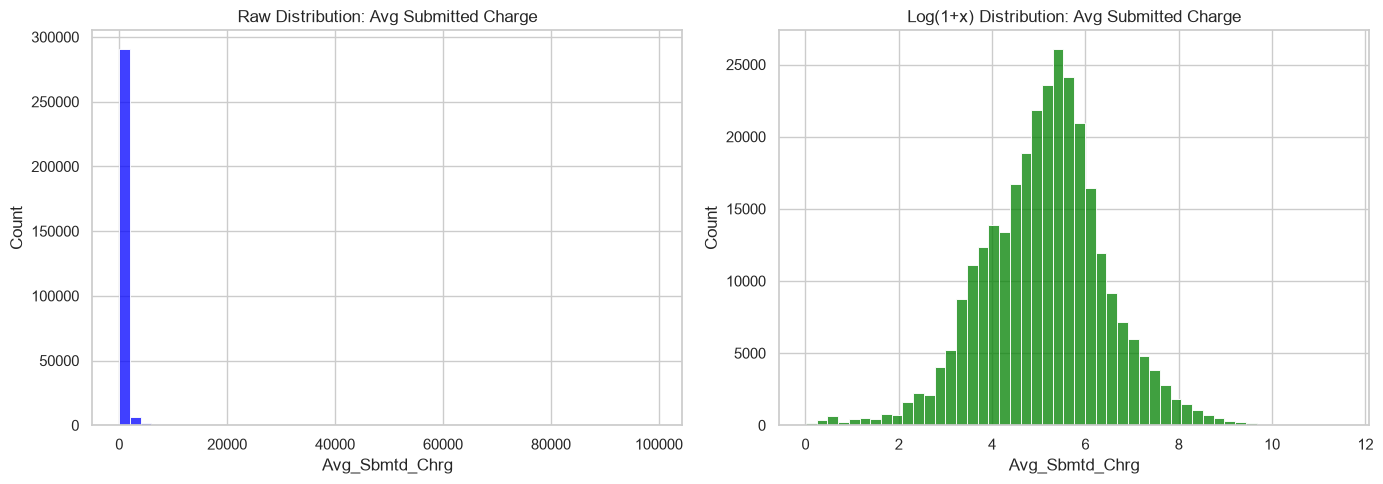

In [7]:
FIG_DIR = "figures" 
os.makedirs(FIG_DIR, exist_ok=True) 

def savefig(name): 
    plt.tight_layout() 
    plt.savefig(f"{FIG_DIR}/{name}.png", dpi=150, bbox_inches="tight")
    plt.show() 

# Sample for heavy plots
s = clean.sample(300_000, random_state=42) 

# 6.1 Raw vs Log Distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw Distribution Plot
sns.histplot(s["Avg_Sbmtd_Chrg"], bins=50, ax=axes[0], color="blue")
axes[0].set_title("Raw Distribution: Avg Submitted Charge")

# Log Transformed Distribution Plot
sns.histplot(np.log1p(s["Avg_Sbmtd_Chrg"]), bins=50, ax=axes[1], color="green")
axes[1].set_title("Log(1+x) Distribution: Avg Submitted Charge")

savefig("raw_vs_log_distribution")

> **Observation:** Submitted charges are extremely right-skewed (mean \$431 vs. median \$180, max \$99,999.99 — likely a reporting cap, since 28 rows sit right at that value). The log(1+x) transform makes the distribution roughly unimodal and much closer to symmetric, centered around \$50–\$400.

### 6.2 Distributions of Other Key Billing Variables

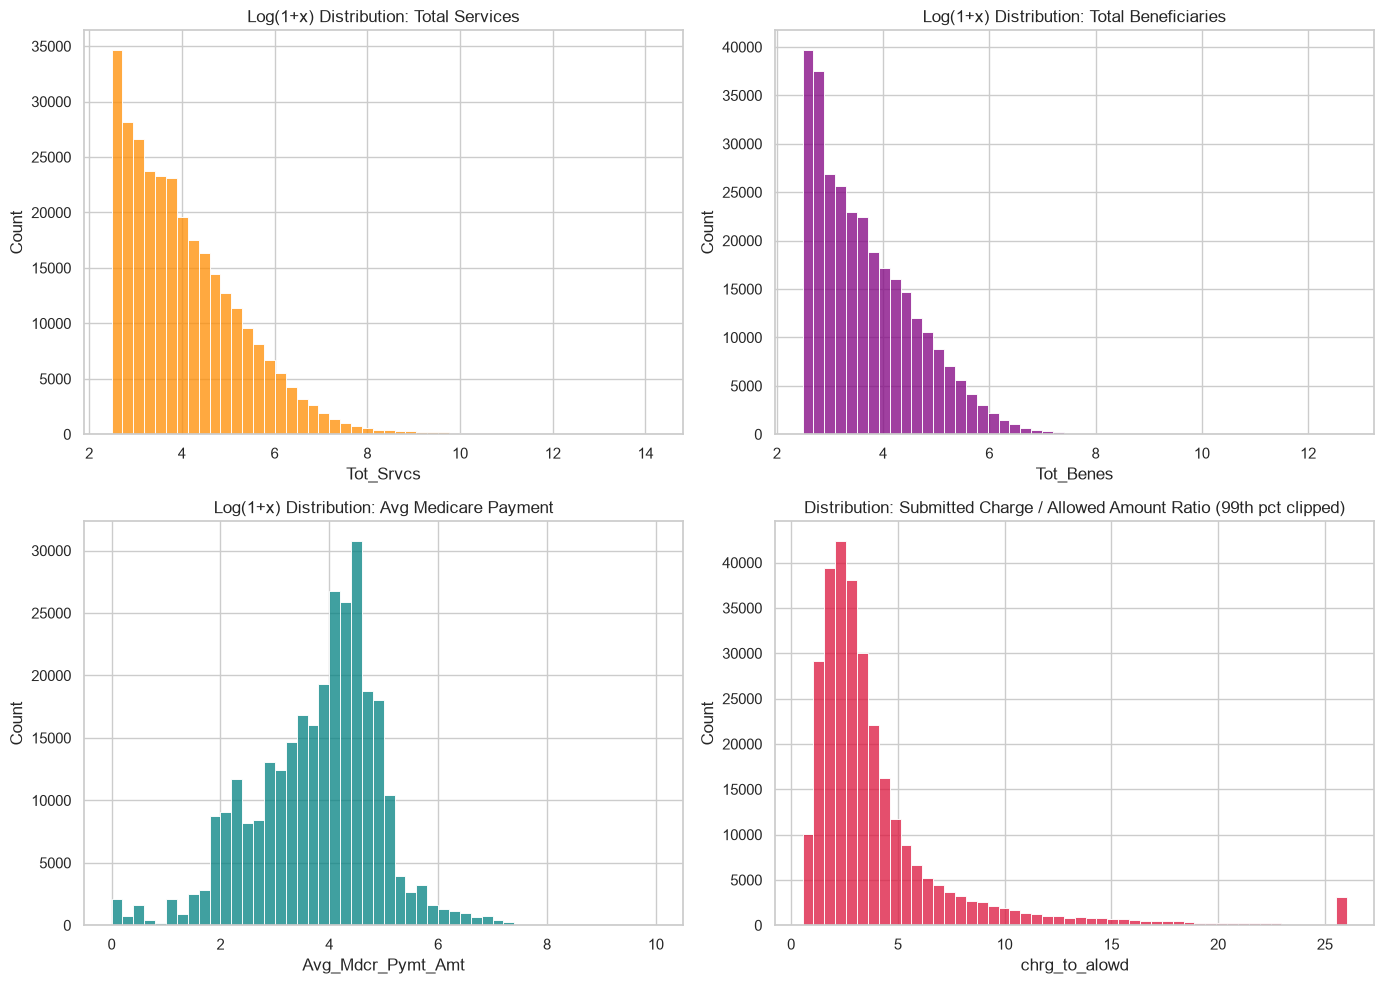

In [8]:
# 6.2 Distributions of Additional Key Variables
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(np.log1p(s["Tot_Srvcs"]), bins=50, ax=axes[0, 0], color="darkorange")
axes[0, 0].set_title("Log(1+x) Distribution: Total Services")

sns.histplot(np.log1p(s["Tot_Benes"]), bins=50, ax=axes[0, 1], color="purple")
axes[0, 1].set_title("Log(1+x) Distribution: Total Beneficiaries")

sns.histplot(np.log1p(s["Avg_Mdcr_Pymt_Amt"]), bins=50, ax=axes[1, 0], color="teal")
axes[1, 0].set_title("Log(1+x) Distribution: Avg Medicare Payment")

clip_val = s["chrg_to_alowd"].quantile(0.99)
sns.histplot(s["chrg_to_alowd"].clip(upper=clip_val), bins=50, ax=axes[1, 1], color="crimson")
axes[1, 1].set_title("Distribution: Submitted Charge / Allowed Amount Ratio (99th pct clipped)")

savefig("key_variable_distributions")


> **Observation:** Total services, beneficiaries, and payment all show the same right-skew pattern as submitted charge. The charge-to-allowed ratio (99th-pct clipped) clusters between roughly 1.5x–4x, with a long tail beyond that; the spike bar at the far right is a clipping artifact (all values above the 99th percentile piling into one bin), not a real cluster at that ratio.

### 6.3 Top Provider Types by Total Medicare Payment

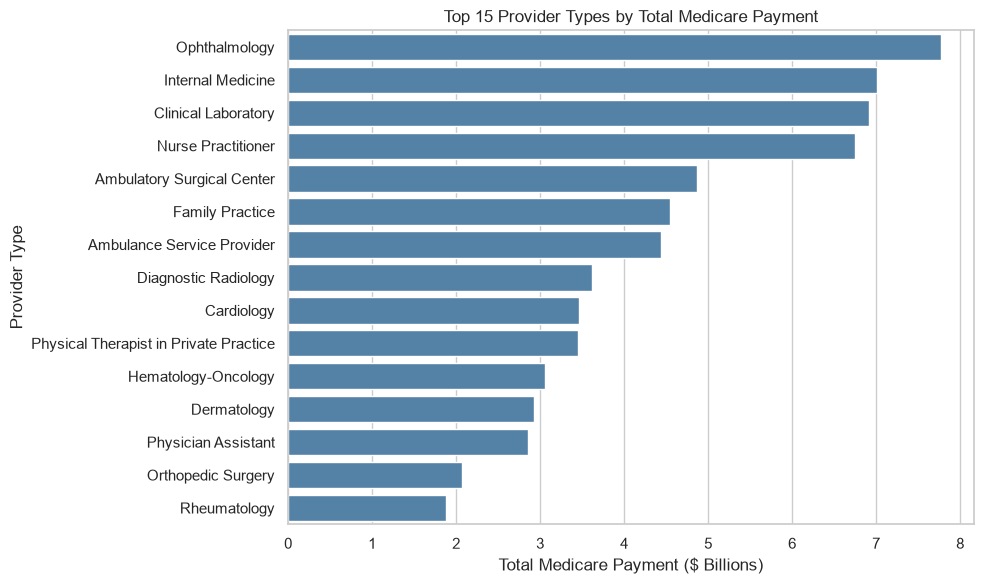

In [9]:
# 6.3 Top Provider Types by Total Medicare Payment
top_types = (
    clean.groupby("Rndrng_Prvdr_Type", observed=True)["tot_pymt"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_types.values / 1e9, y=top_types.index, color="steelblue")
plt.xlabel("Total Medicare Payment ($ Billions)")
plt.ylabel("Provider Type")
plt.title("Top 15 Provider Types by Total Medicare Payment")
savefig("top_provider_types_by_payment")


> **Observation:** Ophthalmology (\$7.8B), Internal Medicine (\$7.0B), Clinical Laboratory (\$6.9B), and Nurse Practitioner (\$6.8B) are the top 4 provider types by total Medicare payment, noticeably ahead of the rest of the top 15 — a small number of specialties account for a disproportionate share of spending.

### 6.4 Facility vs. Non-Facility Billing

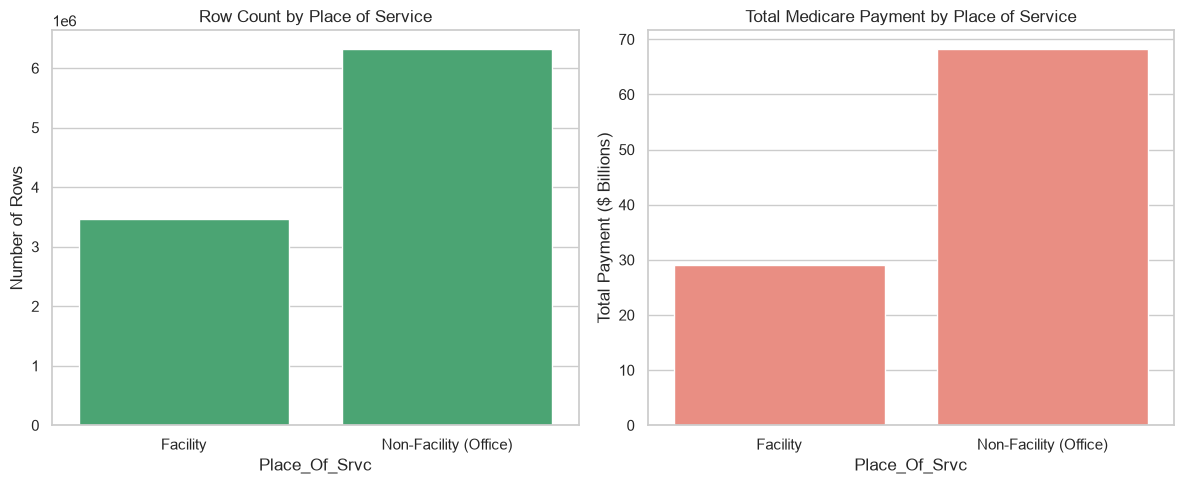

In [10]:
# 6.4 Facility vs. Non-Facility Split
pos_summary = clean.groupby("Place_Of_Srvc", observed=True).agg(
    n_rows=("Rndrng_NPI", "size"),
    total_payment=("tot_pymt", "sum"),
)
pos_summary.index = pos_summary.index.map({"F": "Facility", "O": "Non-Facility (Office)"})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x=pos_summary.index, y=pos_summary["n_rows"], ax=axes[0], color="mediumseagreen")
axes[0].set_title("Row Count by Place of Service")
axes[0].set_ylabel("Number of Rows")

sns.barplot(x=pos_summary.index, y=pos_summary["total_payment"] / 1e9, ax=axes[1], color="salmon")
axes[1].set_title("Total Medicare Payment by Place of Service")
axes[1].set_ylabel("Total Payment ($ Billions)")

savefig("place_of_service_split")


> **Observation:** Non-facility (office) billing accounts for ~65% of rows (6.3M vs. 3.45M) but ~70% of total Medicare payment (~\$68B vs. ~\$29B) — office-based billing dominates both volume *and* dollars, which is somewhat counterintuitive given hospital/facility care is often assumed to be more resource-intensive per claim.

### 6.5 Segment Breakdown (Service / Drug / Mileage)

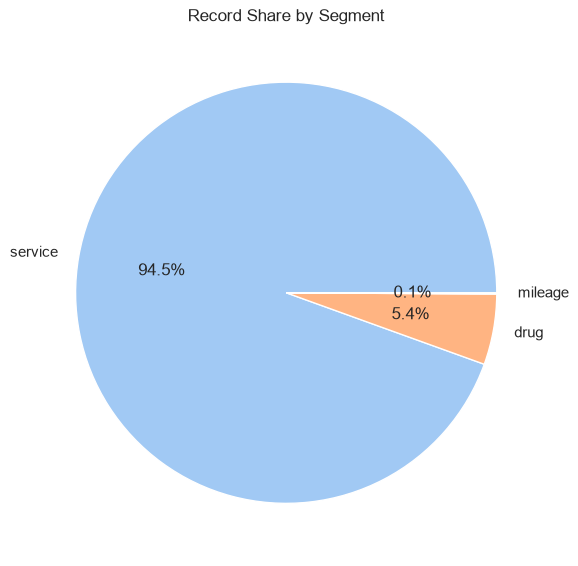

In [11]:
# 6.5 Segment Breakdown (Service / Drug / Mileage)
seg_counts = clean["segment"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(seg_counts.values, labels=seg_counts.index, autopct="%1.1f%%",
        colors=sns.color_palette("pastel"))
plt.title("Record Share by Segment")
savefig("segment_breakdown")


> **Observation:** As expected, the dataset is overwhelmingly regular services (94.5%), with drug billing (5.4%) and mileage (0.1%) as small minority segments. This confirms treating `segment` as a peer-group dimension is worthwhile — drug and mileage billing behave differently enough (see 6.7) that lumping them in with regular services would distort peer comparisons.

### 6.6 Correlation Among Key Numeric Features

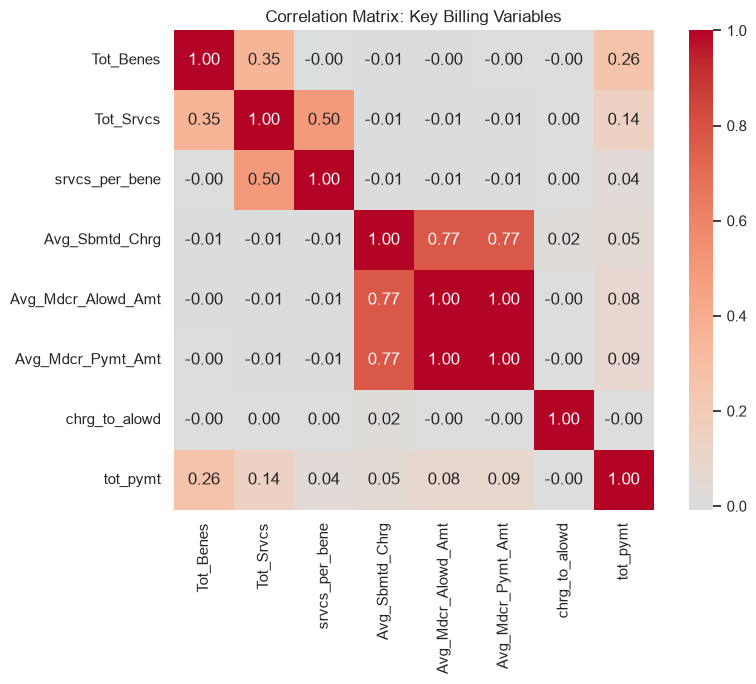

In [12]:
# 6.6 Correlation Among Key Numeric Features
corr_cols = [
    "Tot_Benes", "Tot_Srvcs", "srvcs_per_bene",
    "Avg_Sbmtd_Chrg", "Avg_Mdcr_Alowd_Amt", "Avg_Mdcr_Pymt_Amt",
    "chrg_to_alowd", "tot_pymt",
]
corr = clean[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Matrix: Key Billing Variables")
savefig("correlation_heatmap")


> **Observation:** Submitted charge, allowed amount, and payment amount are all highly correlated (0.77 with charge, ~1.00 between allowed and payment) — allowed and payment are nearly redundant and one could likely be dropped as a model input. The engineered `chrg_to_alowd` ratio shows ~0 Pearson correlation with everything, including its own numerator; this is likely an artifact of the extreme skew in the raw dollar columns rather than evidence the ratio carries no signal, and is worth re-checking with Spearman correlation or on log-transformed values before concluding it's uninformative.

### 6.7 Submitted Charge vs. Medicare Payment (Relationship & Outliers)

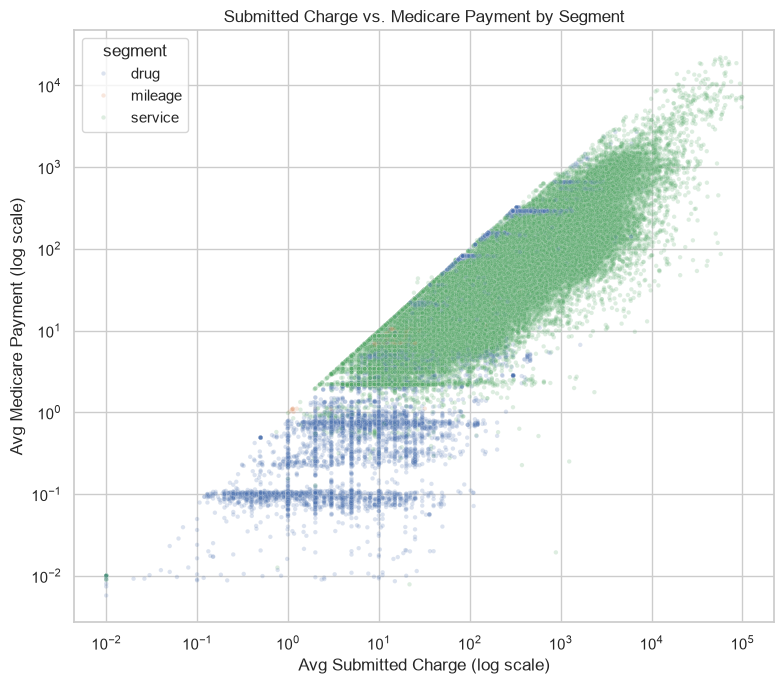

In [13]:
# 6.7 Submitted Charge vs. Medicare Payment
plt.figure(figsize=(8, 7))
sns.scatterplot(
    data=s, x="Avg_Sbmtd_Chrg", y="Avg_Mdcr_Pymt_Amt",
    hue="segment", alpha=0.2, s=10, palette="deep"
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Avg Submitted Charge (log scale)")
plt.ylabel("Avg Medicare Payment (log scale)")
plt.title("Submitted Charge vs. Medicare Payment by Segment")
savefig("submitted_vs_payment_scatter")


> **Observation:** `service` records fall along the expected diagonal (payment scales with submitted charge). The `drug` segment instead forms a flat, decoupled band — payment stays low and roughly constant regardless of the submitted charge — consistent with Part B drugs being reimbursed off an Average Sales Price formula rather than a percentage of what's billed. This is a strong argument for keeping `segment` as a separate peer dimension rather than modeling drug and service rows together.

### 6.8 Peer-Relative Billing Ratio Spread by Provider Type

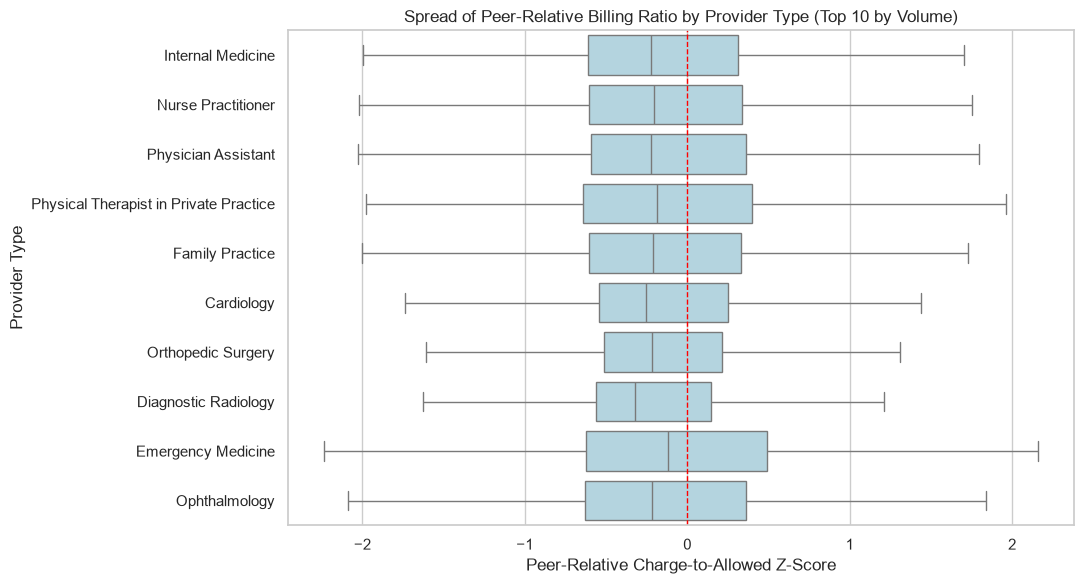

In [14]:
# 6.8 Peer-Relative Charge Ratio Spread by Provider Type (Top 10 by Volume)
top10_types = clean["Rndrng_Prvdr_Type"].value_counts().head(10).index

plt.figure(figsize=(11, 6))
sns.boxplot(
    data=clean[clean["Rndrng_Prvdr_Type"].isin(top10_types)],
    x="chrg_to_alowd_z", y="Rndrng_Prvdr_Type",
    orient="h", showfliers=False, color="lightblue"
)
plt.axvline(0, color="red", linestyle="--", linewidth=1)
plt.xlabel("Peer-Relative Charge-to-Allowed Z-Score")
plt.ylabel("Provider Type")
plt.title("Spread of Peer-Relative Billing Ratio by Provider Type (Top 10 by Volume)")
savefig("peer_zscore_spread_by_type")


> **Observation:** Peer-relative z-scores for the top 10 provider types by volume are all roughly centered near 0, as expected, but whiskers extend out to about ±2 for most types. Cardiology and Diagnostic Radiology show the tightest, most negatively-shifted spread (more homogeneous, slightly below-peer billing), while Emergency Medicine and Physical Therapist in Private Practice show the widest spread (more heterogeneous billing behavior) — meaning true outliers may be easier to isolate within some specialties than others.

## 7. Feature & Target Understanding

**No labeled target exists.** The CMS dataset contains no verified fraud/abuse flag, which is exactly why the project proposal specifies **unsupervised anomaly detection** (Isolation Forest) rather than supervised classification. There is nothing to predict in the traditional sense — instead, the model output *is* a derived quantity we construct: a **0–100 Billing Anomaly Risk Score** per provider–service record.

**Identifier / grouping columns (not model inputs):**
- `Rndrng_NPI` — provider identity (used to *join back* results, not as a feature)
- `HCPCS_Cd`, `Rndrng_Prvdr_Type`, `Place_Of_Srvc`, `segment` — define the **peer group**, not features themselves

**Candidate input features for the Isolation Forest / baseline models:**
- `Tot_Srvcs`, `Tot_Benes`, `srvcs_per_bene` — volume and service intensity
- `Avg_Sbmtd_Chrg`, `Avg_Mdcr_Pymt_Amt`, `chrg_to_alowd` — charge/payment behavior
- Peer-relative versions of all the above: `*_z` (z-score) and `*_pct` (percentile rank) within `Rndrng_Prvdr_Type × Place_Of_Srvc × HCPCS_Cd × segment`

The peer-relative features are expected to matter most, since the whole premise of the project is *comparing a provider to its true peers* rather than flagging high absolute volume (which may simply reflect a busy, legitimate practice).


## 8. Initial Findings & Next Steps

**Data quality**
- Cleaning removed only 512 of 9,781,673 rows (0.0052%) — 422 (0.0043%) for non-US providers, 90 (0.0009%) for logical inconsistencies (services < beneficiaries, beneficiary-days > services, or $0 allowed amount). The raw CMS extract is already very clean.
- Missingness is concentrated entirely in optional identity/address fields — `Rndrng_Prvdr_St2` (78.1%), `Rndrng_Prvdr_MI` (35.4%), `Rndrng_Prvdr_Crdntls` (11.0%), `Rndrng_Prvdr_First_Name` (4.9%) — all of which were dropped or are not used as model features. Every billing metric (`Tot_Benes` through `Avg_Mdcr_Stdzd_Amt`) has 0% missing.
- Two dataset-specific quirks to document rather than "fix": `Tot_Benes` never falls below 11 (CMS suppresses low-beneficiary rows for privacy), and `Avg_Sbmtd_Chrg` has 28 rows sitting at exactly \$99,999.99, suggesting a reporting cap rather than genuine extreme values.

**Distributions & relationships**
- `Avg_Sbmtd_Chrg`, `Tot_Srvcs`, `Tot_Benes`, and `Avg_Mdcr_Pymt_Amt` are all strongly right-skewed; log transforms make them roughly unimodal and much closer to symmetric.
- `Avg_Mdcr_Alowd_Amt` and `Avg_Mdcr_Pymt_Amt` are nearly perfectly correlated (r ≈ 1.00) — likely redundant as separate model inputs. `chrg_to_alowd` shows ~0 Pearson correlation with the raw dollar columns, which needs a follow-up check (Spearman / log-scale correlation) before assuming it adds no signal.
- Ophthalmology, Internal Medicine, Clinical Laboratory, and Nurse Practitioner are the top 4 provider types by total Medicare payment.
- Non-facility (office) billing accounts for ~65% of rows and ~70% of total payment — volume and dollars are concentrated outside the hospital setting.
- The `drug` segment behaves fundamentally differently from `service`: payment stays flat regardless of submitted charge (ASP-based reimbursement), while `service` billing scales proportionally as expected. This confirms `segment` needs to stay a separate peer-group dimension.
- Peer-relative `chrg_to_alowd_z` is centered near 0 for all top-10 provider types (as expected for a z-score) but spread varies meaningfully by specialty — Cardiology/Diagnostic Radiology are tightest, Emergency Medicine/PT are widest.